# Understanding Information Gain

This notebook contains a few interactive visualizations created to better understand how various measures of information gain, such as e.g. 
- the entropy of a distribution $H(\text{prior})$, or 
- the change in entropy $H(\text{prior}) - H(\text{posterior})$ or 
- the KL divergence between prior and posterior $\text{KL}(\text{posterior} || \text{prior})$,

behave when
- varying the levels of epistemic and aleatoric uncertainty in prior and posterior
- increasing the size of the state space from prior to posterior 

The focus of this will be a discrete state space, where we define the prior over the categorical probabilities with a Dirichlet distribution (i.e. $H(\cdot)$ refers to the differential rather than discrete entropy). 


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interactive, FloatSlider, VBox, HTML
import math
import torch

def plot_dirichlet(a1, a2, a3, a4):
    plt.clf()
    
    alphas = [a1, a2, a3, a4]
    categories = ['$s_1$', '$s_2$', '$s_3$', '$s_4$']
    
    # Calculations
    total = sum(alphas)
    means = [a/total for a in alphas]
    variances = [a*(total-a)/(total**2*(total+1)) for a in alphas]
    stds = [math.sqrt(v) for v in variances]
    error_bars = [2*std for std in stds]
    
    # Compute the entropy of the Dirichlet distribution
    entropy = torch.distributions.dirichlet.Dirichlet(torch.tensor(alphas)).entropy().item()
    
    # Draw 3 samples from Dirichlet distribution
    samples = np.random.dirichlet(alphas, size=3)
    
    # Create subplot grid
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes = axes.ravel()
    
    # Plot mean with error bars
    axes[0].bar(categories, means, yerr=error_bars, capsize=5, alpha=0.7)
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel("$p(s' | s,a)$")
    axes[0].set_title('Mean with Uncertainty')
    
    # Plot individual samples
    colors = ['red', 'green', 'blue']
    for i, sample in enumerate(samples):
        axes[i+1].bar(categories, sample, color=colors[i], alpha=0.7)
        axes[i+1].set_ylim(0, 1)
        axes[i+1].set_ylabel("$p(s' | s,a)$")
        axes[i+1].set_title(f'Sample {i+1}')
    
    plt.suptitle('Categorical Distribution with Uncertainty')
    
    # Calculate steps text
    calc_text = f"<pre>Calculation Steps:\n\n"
    calc_text += f"Total α = {total:.3f}\n\n"
    
    for i, cat in enumerate(categories):
        calc_text += f"{cat}:\n"
        calc_text += f"α = {alphas[i]:.3f}\n"
        calc_text += f"Mean = α/total = {alphas[i]:.3f}/{total:.3f} = {means[i]:.3f}\n"
        calc_text += f"Variance = (α * (total - α))/(total² * (total + 1))\n"
        calc_text += f"        = ({alphas[i]:.3f} * ({total:.3f} - {alphas[i]:.3f}))/({total:.3f}² * {(total+1):.3f})\n"
        calc_text += f"        = {variances[i]:.6f}\n"
        calc_text += f"Std Dev = √variance = {stds[i]:.6f}\n"
        calc_text += f"Error Bar (±2σ) = {error_bars[i]:.6f}\n\n"
    calc_text += "</pre>"
    
    plt.tight_layout()
    plt.show()
    display(HTML(calc_text))

widget = interactive(plot_dirichlet,
                   a1=FloatSlider(min=0.1, max=100, step=0.1, value=0.1, description='Category 1'),
                   a2=FloatSlider(min=0.1, max=100, step=0.1, value=0.1, description='Category 2'),
                   a3=FloatSlider(min=0.1, max=100, step=0.1, value=0.1, description='Category 3'),
                   a4=FloatSlider(min=0.1, max=100, step=0.1, value=0.1, description='Category 4'));

display(widget)

interactive(children=(FloatSlider(value=0.1, description='Category 1', min=0.1), FloatSlider(value=0.1, descri…

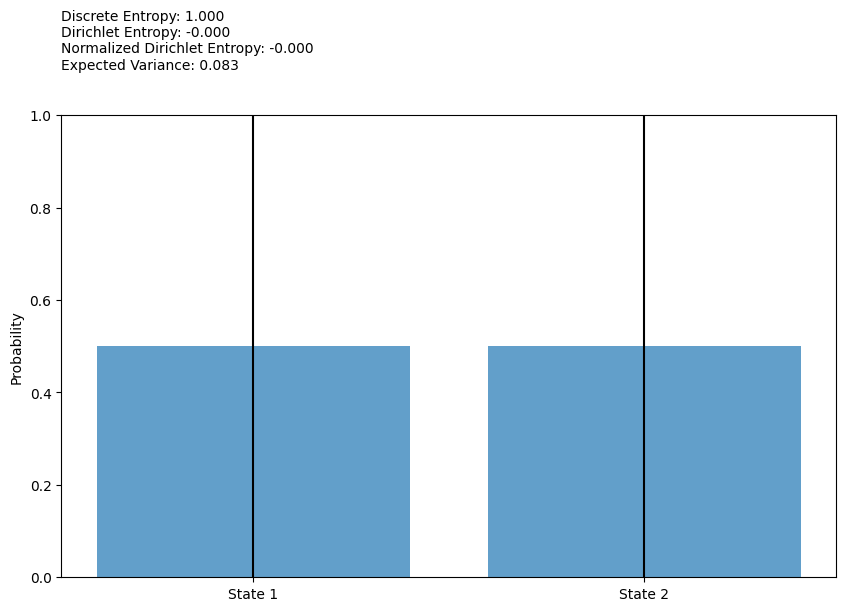

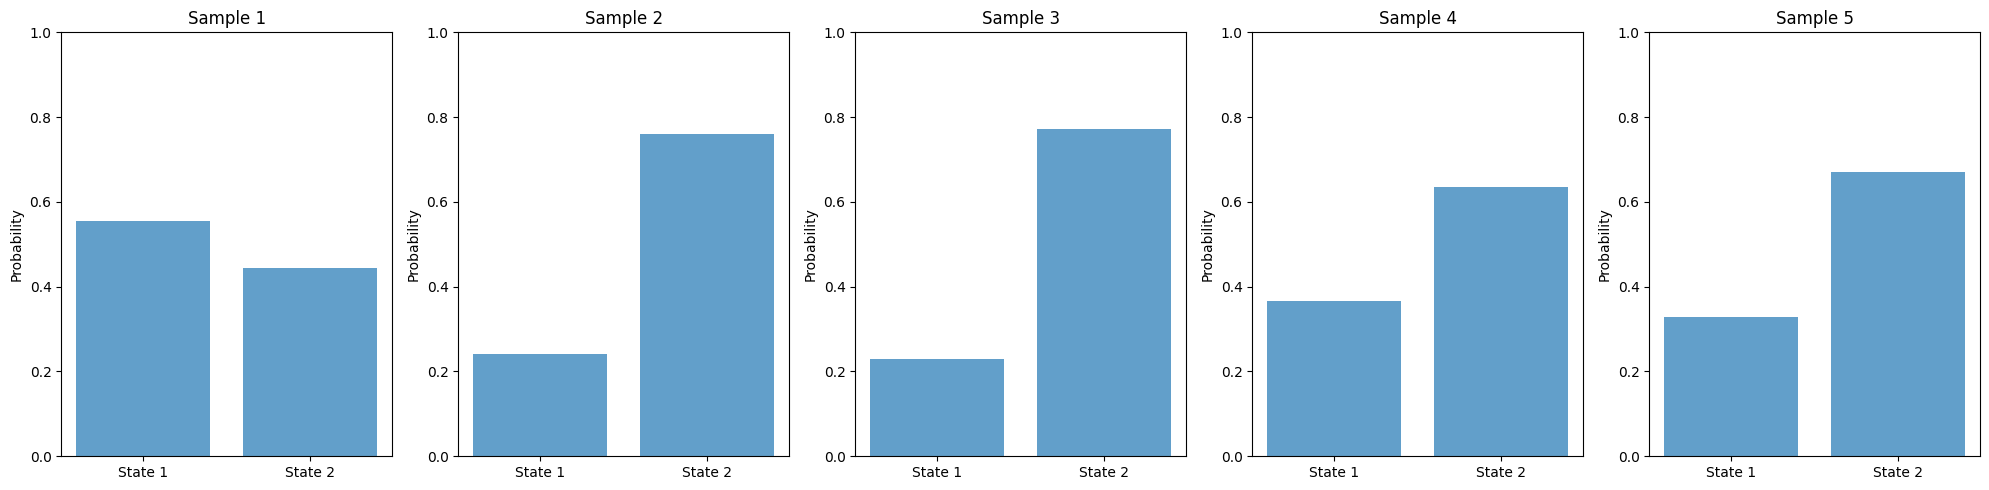

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch

class EntropyVisualizer:
    def __init__(self):
        self.states = [{'label': f'State {i+1}', 'count': 1} for i in range(2)]
        self.setup_widgets()
        self.update_visualization()
    
    def setup_widgets(self):
        # Create text inputs for each state
        self.text_inputs = []
        self.text_input_container = widgets.VBox([])
        self.update_inputs()
        
        # Add/Remove state buttons
        self.add_button = widgets.Button(description='Add State')
        self.remove_button = widgets.Button(description='Remove State')
        self.add_button.on_click(self.add_state)
        self.remove_button.on_click(self.remove_state)
        
        # Display widgets
        self.button_box = widgets.HBox([self.add_button, self.remove_button])
        display(self.button_box)
        display(self.text_input_container)
    
    def update_inputs(self):
        self.text_inputs = []
        for i, state in enumerate(self.states):
            text_input = widgets.FloatText(
                value=state['count'],
                description=state['label'],
                continuous_update=True
            )
            text_input.observe(lambda change, idx=i: self.on_text_input_change(change, idx), names='value')
            self.text_inputs.append(text_input)
        
        self.text_input_container.children = self.text_inputs
    
    def on_text_input_change(self, change, idx):
        self.states[idx]['count'] = change['new']
        self.update_visualization()
    
    def add_state(self, _):
        self.states.append({
            'label': f'State {len(self.states)+1}',
            'count': 1
        })
        self.update_inputs()
        self.update_visualization()
    
    def remove_state(self, _):
        if len(self.states) > 2:
            self.states.pop()
            self.update_inputs()
            self.update_visualization()
    
    def calculate_probabilities(self):
        counts = np.array([state['count'] for state in self.states])
        total = np.sum(counts)
        return counts / total if total > 0 else np.zeros_like(counts)
    
    def calculate_discrete_entropy(self, probs):
        nonzero_probs = probs[probs > 0]
        return -np.sum(nonzero_probs * np.log2(nonzero_probs))
    
    def calculate_dirichlet_entropy(self, counts):
        EPS = 10e-6
        return torch.distributions.dirichlet.Dirichlet(torch.tensor(counts) + EPS).entropy().item()
    
    def update_visualization(self):
        clear_output(wait=True)
        display(self.button_box)
        display(self.text_input_container)
        
        probs = self.calculate_probabilities()
        counts = np.array([state['count'] for state in self.states])
        
        total = np.sum(counts)
        variances = counts * (total - counts) / (total**2 * (total + 1))
        stds = np.sqrt(variances)
        error_bars = 2 * stds
        
        # Calculate entropies
        discrete_entropy = self.calculate_discrete_entropy(probs)
        max_entropy = np.log2(len(self.states))
        dirichlet_entropy = self.calculate_dirichlet_entropy(counts)
        
        # Calculate other measure of uncertainty based on variance
        expected_variance = np.sum(probs * variances)
        
        # Create visualization
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(self.states))
        ax.bar(x, probs, yerr=error_bars, capsize=5, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([state['label'] for state in self.states])
        ax.set_ylabel('Probability')
        ax.set_ylim(0, 1)
        
        # Display metrics
        plt.text(0, 1.1, 
                f'Discrete Entropy: {discrete_entropy:.3f}\n'
                #f'Maximum Possible Entropy: {max_entropy:.3f}\n'
                f'Dirichlet Entropy: {dirichlet_entropy:.3f}\n'
                f'Normalized Dirichlet Entropy: {dirichlet_entropy / np.exp(len(self.states)):.3f}\n'
                f'Expected Variance: {expected_variance:.3f}',
                transform=ax.transAxes)
        
        # Create another plot showing a couple of samples from the Dirichlet distribution, each in a separate subplot
        samples = np.random.dirichlet(counts, size=5)
        fig, axes = plt.subplots(1, 5, figsize=(20, 5))
        axes = axes.ravel()
        for i, sample in enumerate(samples):
            axes[i].bar(x, sample, alpha=0.7)
            axes[i].set_xticks(x)
            axes[i].set_xticklabels([state['label'] for state in self.states])
            axes[i].set_ylabel('Probability')
            axes[i].set_ylim(0, 1)
            axes[i].set_title(f'Sample {i+1}')
        
        plt.tight_layout()
        plt.show()

# Create and display the visualizer
visualizer = EntropyVisualizer()

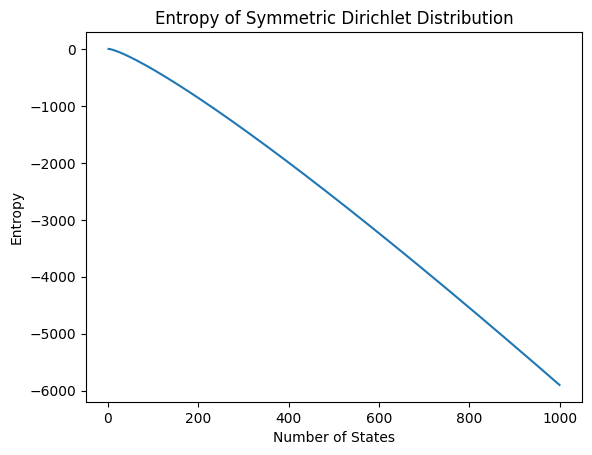

In [3]:
# compute entropy of symmetric dirichlet distribution as a function of number of states
import numpy as np
import matplotlib.pyplot as plt
import torch

n_states = np.arange(2, 1000)
entropies = []
for n in n_states:
    alphas = np.ones(n)
    entropy = torch.distributions.dirichlet.Dirichlet(torch.tensor(alphas)).entropy().item() 
    entropies.append(entropy)
    
plt.plot(n_states, entropies)
plt.xlabel('Number of States')
plt.ylabel('Entropy')
plt.title('Entropy of Symmetric Dirichlet Distribution')
plt.show()

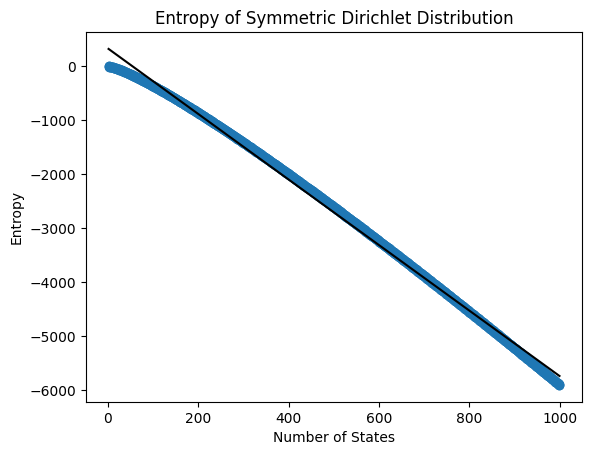

alpha: 336.443
beta: -6.075


In [4]:
# entropy of symmetric dirichlet distribution seems to be decreasing linearly with number of states
# let's fit a linear model to the data to see if this is the case (do not use sklearn)

# Fit a linear model to the data
X = n_states
y = entropies

# Compute the means of X and y
X_mean = np.mean(X)
y_mean = np.mean(y)

# Compute the terms needed for the numator and denominator of beta
numerator = np.sum((X - X_mean) * (y - y_mean))
denominator = np.sum((X - X_mean)**2)

# Compute beta
beta = numerator / denominator

# Compute alpha
alpha = y_mean - beta * X_mean

# Compute the predictions
y_pred = alpha + beta * X

# Plot the data and the prediction
plt.plot(X, y, 'o')
plt.plot(X, y_pred, 'k-')
plt.xlabel('Number of States')
plt.ylabel('Entropy')
plt.title('Entropy of Symmetric Dirichlet Distribution')
plt.show()

# print coefficients
print(f'alpha: {alpha:.3f}')
print(f'beta: {beta:.3f}')

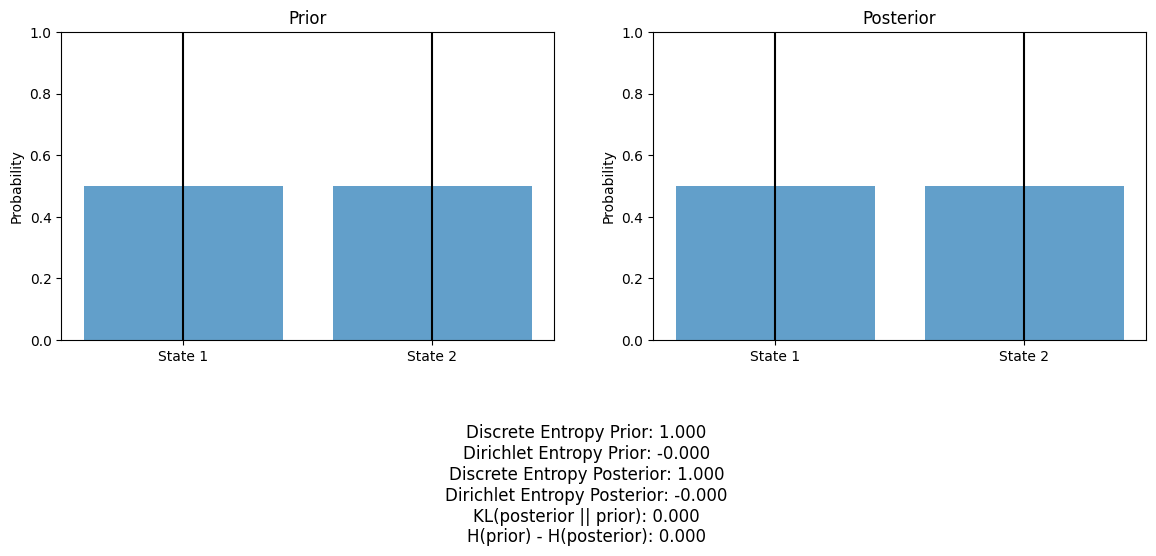

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch

class EntropyVisualizer:
    def __init__(self):
        self.states1 = [{'label': f'State {i+1}', 'count': 1} for i in range(2)]
        self.states2 = [{'label': f'State {i+1}', 'count': 1} for i in range(2)]
        self.setup_widgets()
        self.update_visualization()
    
    def setup_widgets(self):
        # Create text inputs for each state in both distributions
        self.text_inputs1 = []
        self.text_inputs2 = []
        self.text_input_container1 = widgets.VBox([])
        self.text_input_container2 = widgets.VBox([])
        self.update_inputs()
        
        # Add/Remove state buttons for both distributions
        self.add_button1 = widgets.Button(description='Add State to Prior Dist')
        self.remove_button1 = widgets.Button(description='Remove State from Prior Dist')
        self.add_button2 = widgets.Button(description='Add State to Posterior Dist')
        self.remove_button2 = widgets.Button(description='Remove State from Posterior Dist')
        self.add_button1.on_click(self.add_state1)
        self.remove_button1.on_click(self.remove_state1)
        self.add_button2.on_click(self.add_state2)
        self.remove_button2.on_click(self.remove_state2)
        
        # Display widgets
        self.button_box1 = widgets.HBox([self.add_button1, self.remove_button1])
        self.button_box2 = widgets.HBox([self.add_button2, self.remove_button2])
        display(self.button_box1)
        display(self.text_input_container1)
        display(self.button_box2)
        display(self.text_input_container2)
    
    def update_inputs(self):
        self.text_inputs1 = []
        self.text_inputs2 = []
        for i, state in enumerate(self.states1):
            text_input = widgets.FloatText(
                value=state['count'],
                description=state['label'],
                continuous_update=True
            )
            text_input.observe(lambda change, idx=i: self.on_text_input_change1(change, idx), names='value')
            self.text_inputs1.append(text_input)
        
        for i, state in enumerate(self.states2):
            text_input = widgets.FloatText(
                value=state['count'],
                description=state['label'],
                continuous_update=True
            )
            text_input.observe(lambda change, idx=i: self.on_text_input_change2(change, idx), names='value')
            self.text_inputs2.append(text_input)
        
        self.text_input_container1.children = self.text_inputs1
        self.text_input_container2.children = self.text_inputs2
    
    def on_text_input_change1(self, change, idx):
        self.states1[idx]['count'] = change['new']
        self.update_visualization()
    
    def on_text_input_change2(self, change, idx):
        self.states2[idx]['count'] = change['new']
        self.update_visualization()
    
    def add_state1(self, _):
        self.states1.append({
            'label': f'State {len(self.states1)+1}',
            'count': 1
        })
        self.update_inputs()
        self.update_visualization()
    
    def remove_state1(self, _):
        if len(self.states1) > 2:
            self.states1.pop()
            self.update_inputs()
            self.update_visualization()
    
    def add_state2(self, _):
        self.states2.append({
            'label': f'State {len(self.states2)+1}',
            'count': 1
        })
        self.update_inputs()
        self.update_visualization()
    
    def remove_state2(self, _):
        if len(self.states2) > 2:
            self.states2.pop()
            self.update_inputs()
            self.update_visualization()
    
    def calculate_probabilities(self, states):
        counts = np.array([state['count'] for state in states])
        total = np.sum(counts)
        return counts / total if total > 0 else np.zeros_like(counts)
    
    def calculate_discrete_entropy(self, probs):
        nonzero_probs = probs[probs > 0]
        return -np.sum(nonzero_probs * np.log2(nonzero_probs))
    
    def calculate_dirichlet_entropy(self, counts):
        EPS = 10e-6
        return torch.distributions.dirichlet.Dirichlet(torch.tensor(counts) + EPS).entropy().item()
    
    def calculate_kl_divergence(self, counts1, counts2):
        # compute KL divergence between the two distributions
        EPS = 10e-6
        dist1 = torch.distributions.dirichlet.Dirichlet(torch.tensor(counts1) + EPS)
        dist2 = torch.distributions.dirichlet.Dirichlet(torch.tensor(counts2) + EPS)
        return torch.distributions.kl.kl_divergence(dist1, dist2).item()
    
    def update_visualization(self):
        clear_output(wait=True)
        display(self.button_box1)
        display(self.text_input_container1)
        display(self.button_box2)
        display(self.text_input_container2)
        
        probs1 = self.calculate_probabilities(self.states1)
        probs2 = self.calculate_probabilities(self.states2)
        counts1 = np.array([state['count'] for state in self.states1])
        counts2 = np.array([state['count'] for state in self.states2])
        
        total1 = np.sum(counts1)
        total2 = np.sum(counts2)
        variances1 = counts1 * (total1 - counts1) / (total1**2 * (total1 + 1))
        variances2 = counts2 * (total2 - counts2) / (total2**2 * (total2 + 1))
        stds1 = np.sqrt(variances1)
        stds2 = np.sqrt(variances2)
        error_bars1 = 2 * stds1
        error_bars2 = 2 * stds2
        
        # Calculate entropies
        discrete_entropy1 = self.calculate_discrete_entropy(probs1)
        discrete_entropy2 = self.calculate_discrete_entropy(probs2)
        dirichlet_entropy1 = self.calculate_dirichlet_entropy(counts1)
        dirichlet_entropy2 = self.calculate_dirichlet_entropy(counts2)
        
        # Calculate IG = KL(posterior || prior)
        kl_divergence = self.calculate_kl_divergence(counts2, counts1)
        
        # Compute IG = H(prior) - H(posterior)
        entropy_diff = dirichlet_entropy1 - dirichlet_entropy2
        
        # Create visualization
        fig, ax = plt.subplots(1, 2, figsize=(14, 4))
        x1 = np.arange(len(self.states1))
        x2 = np.arange(len(self.states2))
        ax[0].bar(x1, probs1, yerr=error_bars1, capsize=5, alpha=0.7)
        ax[0].set_xticks(x1)
        ax[0].set_xticklabels([state['label'] for state in self.states1])
        ax[0].set_ylabel('Probability')
        ax[0].set_ylim(0, 1)
        ax[0].set_title('Prior')
        
        ax[1].bar(x2, probs2, yerr=error_bars2, capsize=5, alpha=0.7)
        ax[1].set_xticks(x2)
        ax[1].set_xticklabels([state['label'] for state in self.states2])
        ax[1].set_ylabel('Probability')
        ax[1].set_ylim(0, 1)
        ax[1].set_title('Posterior')
        
        # Display metrics
        fig.text(0.5, -0.1, 
                f'Discrete Entropy Prior: {discrete_entropy1:.3f}\n'
                f'Dirichlet Entropy Prior: {dirichlet_entropy1:.3f}\n'
                f'Discrete Entropy Posterior: {discrete_entropy2:.3f}\n'
                f'Dirichlet Entropy Posterior: {dirichlet_entropy2:.3f}\n'
                f'KL(posterior || prior): {kl_divergence:.3f}\n'
                f'H(prior) - H(posterior): {entropy_diff:.3f}',
                ha='center', va='top', fontsize=12)
        
        plt.show()

# Create and display the visualizer
visualizer = EntropyVisualizer()

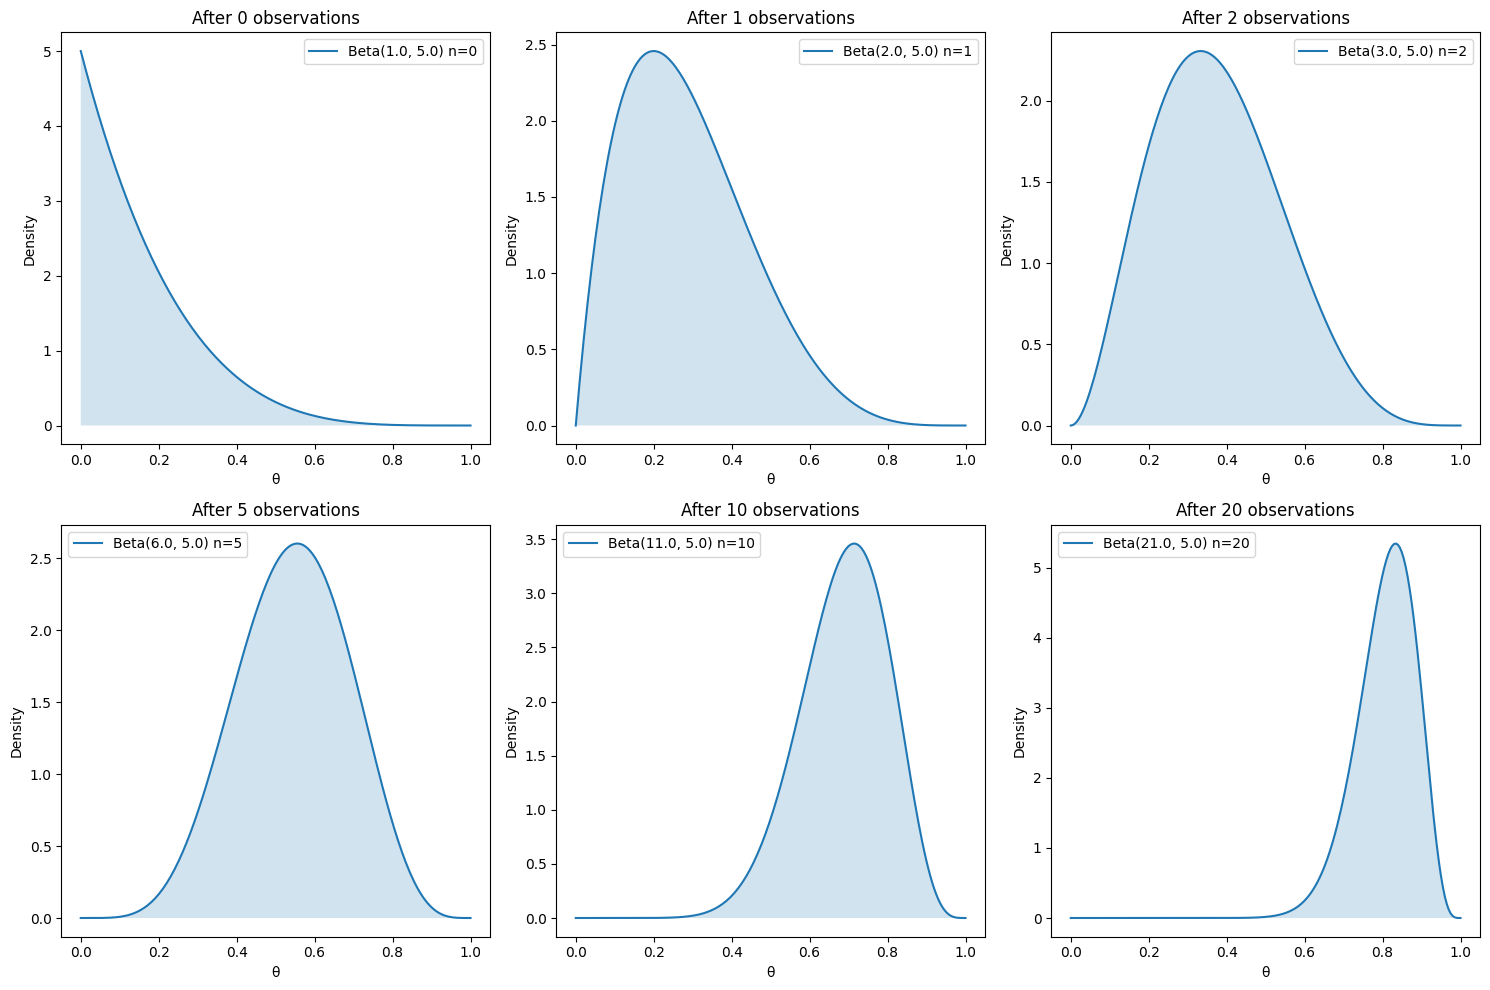

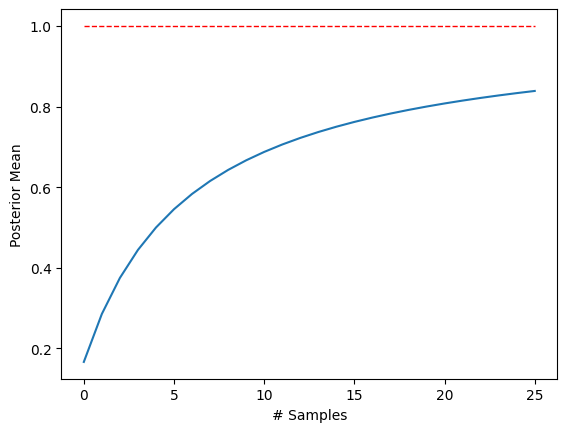

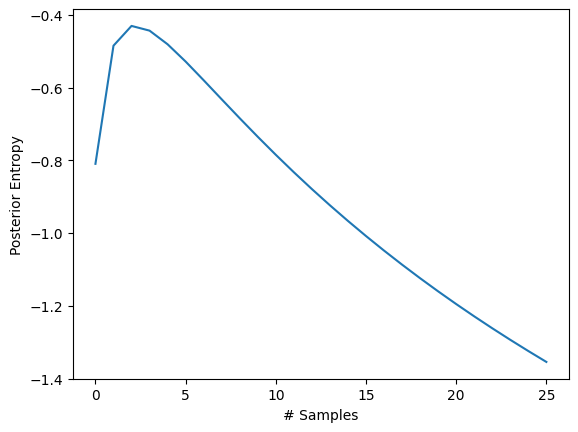

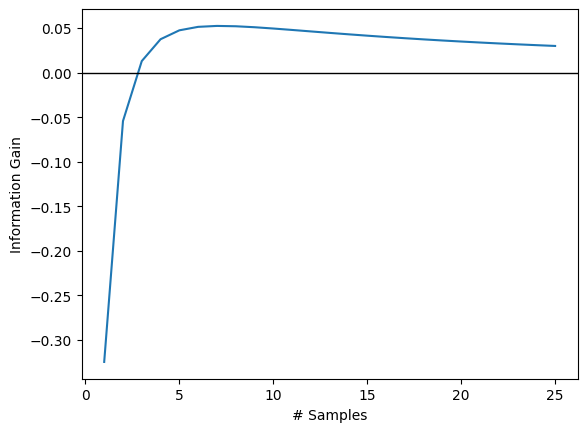

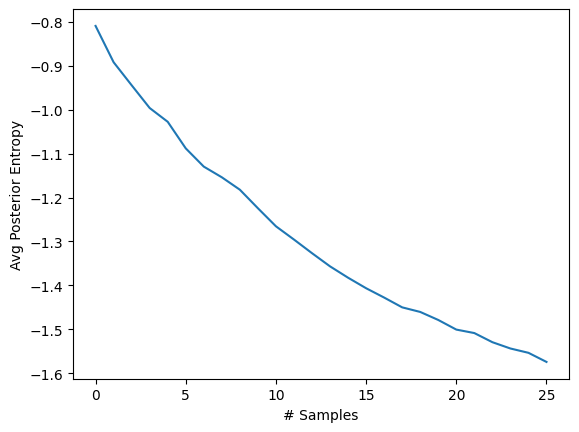

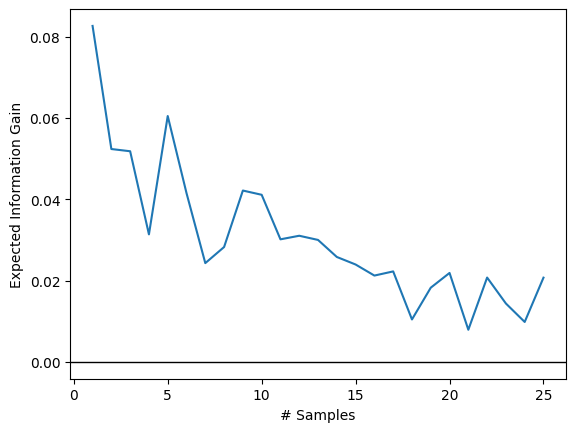

In [ ]:
# adapted from https://gist.github.com/fredcallaway/f6da260e410fafc3997059c3599518ff
# found in: https://todd.gureckislab.org/2021/05/05/negative-information

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Parameters
alpha, beta = 1, 5
max_n = 25
n = np.arange(max_n + 1)

# Function to calculate entropy of Beta distribution
def beta_entropy(a, b):
    return stats.beta(a, b).entropy()

# Function to plot beta distribution
def plot_beta_distribution(ax, a, b, label=''):
    x = np.linspace(0, 1, 200)
    dist = stats.beta(a, b)
    y = dist.pdf(x)
    ax.plot(x, y, label=f'Beta({a:.1f}, {b:.1f}) {label}')
    ax.fill_between(x, y, alpha=0.2)
    ax.set_xlabel('θ')
    ax.set_ylabel('Density')
    ax.legend()

# Create a figure to show evolution of distribution
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()

# Plot distributions for different number of observations
sample_points = [0, 1, 2, 5, 10, 20]  # Points we want to visualize
for i, n_obs in enumerate(sample_points):
    plot_beta_distribution(axs[i], alpha + n_obs, beta, 
                         f'n={n_obs}')
    axs[i].set_title(f'After {n_obs} observations')

plt.tight_layout()
plt.show()

# Calculate posteriors (assuming θ = 1, always heads)
posteriors = [stats.beta(alpha + ni, beta) for ni in n]

# Plot 1: Posterior Mean
plt.figure()
plt.plot(n, [dist.mean() for dist in posteriors])
plt.plot([0, max_n], [1, 1], 'r--', linewidth=1)
plt.xlabel('# Samples')
plt.ylabel('Posterior Mean')
plt.xticks(np.arange(0, max_n+1, 5))
plt.show()

# Plot 2: Posterior Entropy
plt.figure()
plt.plot(n, [beta_entropy(alpha + ni, beta) for ni in n])
plt.xlabel('# Samples')
plt.ylabel('Posterior Entropy')
plt.xticks(np.arange(0, max_n+1, 5))
plt.show()

# Plot 3: Information Gain
entropies = np.array([beta_entropy(alpha + ni, beta) for ni in n])
info_gains = -np.diff(entropies)
plt.figure()
plt.plot(n[1:], info_gains)
plt.axhline(y=0, color='black', linewidth=1)
plt.xlabel('# Samples')
plt.ylabel('Information Gain')
plt.xticks(np.arange(0, max_n+1, 5))
plt.show()

# Monte Carlo simulation
n_sim = 100
prior = stats.beta(alpha, beta)

# Initialize array for average entropy
avg_entropy = np.zeros(max_n + 1)
avg_entropy[0] = beta_entropy(alpha, beta)

# Run simulation
for _ in range(n_sim):
    theta = prior.rvs()
    data = stats.bernoulli.rvs(theta, size=max_n)
    cum_heads = np.cumsum(data)
    cum_tails = np.cumsum(1 - data)
    
    for i in range(max_n):
        avg_entropy[i + 1] += beta_entropy(alpha + cum_heads[i], beta + cum_tails[i])

# Average the results
avg_entropy[1:] /= n_sim

# Plot 4: Average Posterior Entropy
plt.figure()
plt.plot(n, avg_entropy)
plt.xlabel('# Samples')
plt.ylabel('Avg Posterior Entropy')
plt.xticks(np.arange(0, max_n+1, 5))
plt.show()

# Plot 5: Expected Information Gain
plt.figure()
plt.plot(n[1:], -np.diff(avg_entropy))
plt.axhline(y=0, color='black', linewidth=1)
plt.xlabel('# Samples')
plt.ylabel('Expected Information Gain')
plt.xticks(np.arange(0, max_n+1, 5))
plt.show()